# **Capstone Project: [Deteksi Penyakit pada Tanaman Kelapa Sawit]**
**ID Group:** LAI25-RM112

**Anggota Kelompok:**
- A200YBF418_Refanda Surya Saputra - A200YBF418@devacademy.id
- A270YAF435_Risky Fahriza - A270YAF435@devacademy.id
- A528YBF449_Sebastian Luth Hasibuan - A528YBF449@devacademy.id
- A184YBF450_Sefza Auma Alam - A184YBF450@devacademy.id

## **Import Libraries/Packages**

In [3]:
import os
import random
import shutil
import warnings
import zipfile

import cv2
import dagshub
import gdown
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from IPython.display import FileLink
from PIL import Image
from skimage import img_as_ubyte
from skimage import io
from skimage.exposure import adjust_gamma
from skimage.transform import rotate, AffineTransform, warp
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2
from tensorflow.keras.applications.resnet_v2 import ResNet50V2
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, \
    GlobalAveragePooling2D
from tensorflow.keras.layers import Input, Rescaling
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.saved_model import save
from tqdm.notebook import tqdm as tq

warnings.simplefilter(action='ignore', category=FutureWarning)

print(tf.__version__)

2.18.0


## **Init Dagshub**

In [4]:
dagshub.init(repo_owner='refandasuryasaputra', repo_name='CP-Laskar-AI-LAI25-RM112', mlflow=True)

Initialized MLflow to track repo "refandasuryasaputra/CP-Laskar-AI-LAI25-RM112"

Repository refandasuryasaputra/CP-Laskar-AI-LAI25-RM112 initialized!

## **Loading Data**

### **Preparation Data**

#### **Using Kaggle Notebook/Remote Server**

In [5]:
# Ketika menggunakan Kaggle Notebook
kaggle_input_path = '/kaggle/input/palm-disease-dataset/palm-disease-dataset'

kaggle_output_path = '/kaggle/working/palm-disease-dataset'

if not os.path.exists(kaggle_output_path):
    os.makedirs(kaggle_output_path)

try:
    shutil.copytree(kaggle_input_path, kaggle_output_path, dirs_exist_ok=True)
    print(f"Berhasil menyalin dataset dari '{kaggle_input_path}' ke {kaggle_output_path}")
except Exception as e:
    print(f"Unexpected error: {e}")

Berhasil menyalin dataset dari '/kaggle/input/palm-disease-dataset/palm-disease-dataset' ke /kaggle/working/palm-disease-dataset


### **Checking Dataset**

In [6]:
# Mengecek label pada dataset
palm_disease_path = "/kaggle/working/palm-disease-dataset"

# Menyimpan label
list_label = os.listdir(palm_disease_path)

# Menampilkan list label
list_label

['Fungal Disease', 'Magnesium Deficiency', 'Scale Insect', 'Healthy']

In [ ]:
# Membuat dictionary untuk menyimpan gambar untuk setiap kelas dalam data_tf
palm_disease_image = {}

# Menentukan path sumber dataset
source_path = "/kaggle/working/palm-disease-dataset/"

for i in os.listdir(source_path):
    palm_disease_image[i] = os.listdir(source_path + i)

# menampilkan secara acak 5 gambar untuk masing-masing kelas
fig, ax = plt.subplots(4, 5, figsize=(15, 20))

for i, label in enumerate(os.listdir(source_path)):
    images = np.random.choice(palm_disease_image[label], 5, replace=False)
    for j, leaf_image in enumerate(images):
        img_path = os.path.join(source_path, label, leaf_image)
        img = Image.open(img_path)
        ax[i, j].imshow(img)
        ax[i, j].set(xlabel=label, xticks=[], yticks=[])

fig.tight_layout()

In [7]:
# Membuat fungsi untuk melihat jumlah image tiap-tiap kelas
def get_image_count(img_dataset_path):
    image_count = {}
    for img_label in os.listdir(img_dataset_path):
        image_count[img_label] = len(os.listdir(os.path.join(img_dataset_path, img_label)))
    return image_count


# Menentukan path sumber dataset
source_path = "/kaggle/working/palm-disease-dataset/"
print(get_image_count(source_path))

{'Fungal Disease': 58, 'Magnesium Deficiency': 59, 'Scale Insect': 66, 'Healthy': 56}


### **Distribution Plot of Class Dataset**

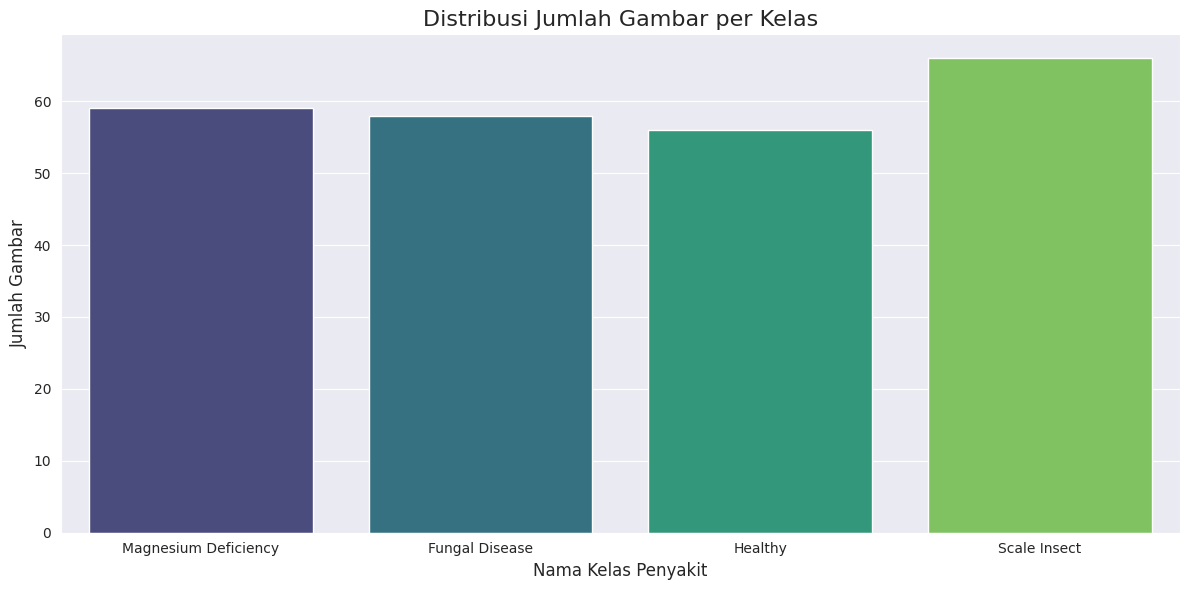

In [9]:
def plot_distribution(path):
    # Membuat daftar yang menyimpan data_tf untuk setiap nama file, path file, dan label dalam data_tf
    file_name = []
    labels = []
    full_path = []

    # Mendapatkan nama file gambar, path file, dan label satu per satu dengan looping, dan simpan sebagai DataFrame
    for path, subdirs, files in os.walk(path):
        for name in files:
            file_name.append(name)
            labels.append(path.split('/')[-1])
            full_path.append(os.path.join(path, name))

    distribution_train = pd.DataFrame({
        'path': full_path,
        'file_name': file_name,
        'labels': labels
    })
    for name in files:
        file_name.append(name)
        labels.append(path.split('/')[-1])

    # Plot distribusi gambar setiap kelas
    plt.figure(figsize=(12, 6))
    sns.set_style('darkgrid')
    sns.countplot(data=distribution_train, x='labels', palette='viridis')

    plt.title("Distribusi Jumlah Gambar per Kelas", fontsize=16)
    plt.xlabel("Nama Kelas Penyakit", fontsize=12)
    plt.ylabel("Jumlah Gambar", fontsize=12)
    plt.tight_layout()
    plt.show()


plot_distribution(source_path)

## **Preprocessing Data**

### **Spliting Data**

In [8]:
# Membuat variabel untuk menampung lokasi folder dari dataset gambar
source_path = '/kaggle/working/palm-disease-dataset/'

file_name = []
labels = []
full_path = []

for path, subdirs, files in os.walk(source_path):
    for name in files:
        file_name.append(name)
        labels.append(path.split('/')[-1])
        full_path.append(os.path.join(path, name))

# Memasukkan variabel yang sudah dikumpulkan pada looping di atas menjadi sebuah DataFrame
image_df = pd.DataFrame({
    'file_name': file_name,
    'labels': labels,
    'full_path': full_path
})

# Melihat jumlah data_tf gambar pada masing-masing label
image_df['labels'].value_counts()

labels
Scale Insect            66
Magnesium Deficiency    59
Fungal Disease          58
Healthy                 56
Name: count, dtype: int64

In [9]:
# variabel yang digunaka pada pemisahan data_tf ini, di mana variabel x = data_tf path dan y = data_tf labels
X = image_df['full_path']
y = image_df['labels']

# Split dataset awal menjadi data_tf train dan temp (test dan validasi)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Menyatukan ke dalam maisng-masing DataFrame
df_train = pd.DataFrame({
    'path': X_train,
    'labels': y_train,
    'set': 'train'
})

df_test = pd.DataFrame({
    'path': X_test,
    'labels': y_test,
    'set': 'test'
})

# Menggabungkan DataFrame df_train, df_test, dan df_validation
df_all = pd.concat([df_train, df_test], ignore_index=True)
print(df_all.groupby(['set', 'labels']).size())

set    labels              
test   Fungal Disease          12
       Healthy                 11
       Magnesium Deficiency    12
       Scale Insect            13
train  Fungal Disease          46
       Healthy                 45
       Magnesium Deficiency    47
       Scale Insect            53
dtype: int64


In [10]:
# Mengecek sampel data_tf
print(df_all.sample(5))

                                                  path                labels  \
165  /kaggle/working/palm-disease-dataset/Scale Ins...          Scale Insect   
142  /kaggle/working/palm-disease-dataset/Scale Ins...          Scale Insect   
154  /kaggle/working/palm-disease-dataset/Healthy/I...               Healthy   
106  /kaggle/working/palm-disease-dataset/Magnesium...  Magnesium Deficiency   
150  /kaggle/working/palm-disease-dataset/Scale Ins...          Scale Insect   

       set  
165  train  
142  train  
154  train  
106  train  
150  train  


In [11]:
# Memanggil dataset asli yang berisi keseluruhan data_tf gambar yang sesuai dengan labelnya
datasource_path = '/kaggle/working/palm-disease-dataset/'

# Membuat variabel dataset, tempat menampung data_tf yang telah dilakukan splitting
dataset_path = '/kaggle/working/final-dataset/'

for index, row in tq(df_all.iterrows()):
    file_path = row['path']

    if not os.path.exists(file_path):
        file_path = os.path.join(datasource_path, row['labels'], row['image'].split('.')[0])

    # Membuat direktori tujuan folder
    if not os.path.exists(os.path.join(dataset_path, row['set'], row['labels'])):
        os.makedirs(os.path.join(dataset_path, row['set'], row['labels']))

    # Menentukan tujuan file
    destination_file_name = file_path.split('/')[-1]
    destination_path = os.path.join(dataset_path, row['set'], row['labels'], destination_file_name)

    # Memindahkan file ke direktori tujuan
    if not os.path.exists(destination_path):
        shutil.copy2(file_path, destination_path)

0it [00:00, ?it/s]

### **Data Augmentation**

In [12]:
# Membuat fungsi untuk melakukan rotasi berlawanan arah jarum jam
def anticlockwise_rotation(raw_image):
    aug_image = cv2.cvtColor(raw_image, cv2.COLOR_RGB2BGR)
    aug_image = cv2.resize(aug_image, (224, 224))
    angle = random.randint(0, 180)
    return rotate(aug_image, angle)


# Membuat fungsi untuk melakukan rotasi searah jarum ram
def clockwise_rotation(raw_image):
    aug_image = cv2.cvtColor(raw_image, cv2.COLOR_RGB2BGR)
    aug_image = cv2.resize(aug_image, (224, 224))
    angle = random.randint(0, 180)
    return rotate(aug_image, -angle)


# Membuat fungsi untuk memberikan efek peningkatan kecerahan pada gambar
def add_brightness(raw_image):
    aug_image = cv2.cvtColor(raw_image, cv2.COLOR_RGB2BGR)
    aug_image = cv2.resize(aug_image, (224, 224))
    aug_image = adjust_gamma(aug_image, gamma=0.5, gain=1)
    return aug_image


# Membuat fungsi untuk memberikan efek pergeseran acak pada gambar
def sheared(raw_image):
    aug_image = cv2.cvtColor(raw_image, cv2.COLOR_RGB2BGR)
    aug_image = cv2.resize(aug_image, (224, 224))
    transform = AffineTransform(shear=0.2)
    shear_img = warp(aug_image, transform, mode='wrap')
    return shear_img


# Membuat fungsi untuk melakukan pergeseran melengkung pada gambar
def warp_shift(raw_image):
    aug_image = cv2.cvtColor(raw_image, cv2.COLOR_RGB2BGR)
    aug_image = cv2.resize(aug_image, (224, 224))
    transform = AffineTransform(translation=(0, 40))
    warp_img = warp(aug_image, transform, mode='wrap')
    return warp_img

In [13]:
# Membuat varabel transofrmasi yang akan menyimpan semua proses pra-pemrosesan yang telah dilakukan sebelumnya
transformations = {
    'anticlockwise_rotation': anticlockwise_rotation,
    'clockwise_rotation': clockwise_rotation,
    'add_brightness': add_brightness,
    'shear_image': sheared,
    'warp_shift': warp_shift
}


def generate_augmented_image(image_class_name, source_image_path, num_augmented_images):
    img_processed_path = os.path.join(source_image_path, image_class_name)

    processed_images = []

    for raw_image in os.listdir(img_processed_path):
        processed_images.append(os.path.join(img_processed_path, raw_image))

    images_to_generate = num_augmented_images - len(os.listdir(img_processed_path))

    i = 1

    while i <= images_to_generate:
        random_image = random.choice(processed_images)

        try:
            original_image = io.imread(random_image)
            transformed_image = None

            num_transformations_to_apply = random.randint(1, len(transformations))

            num_transformations = 0

            while num_transformations <= num_transformations_to_apply:
                key = random.choice(list(transformations))
                transformed_image = transformations[key](original_image)
                num_transformations += 1

            new_image_path = "%s/augmented_image_%s.jpg" % (img_processed_path, i)
            transformed_image = img_as_ubyte(transformed_image)
            cv2.imwrite(new_image_path, transformed_image)
            i += 1
        except Exception as exception:
            print('Could not read the', image, ':', exception, 'hence skipping it.')

In [14]:
source_path = '/kaggle/working/final-dataset/train/'

for label in list_label:
    generate_augmented_image(label, source_path, 400)

print("Berhasil melakukan augmentasi gambar")

Berhasil melakukan augmentasi gambar


### **Set Splitting Directory & Checking Splitting Result**

In [6]:
# Mendefinisikan direktori daset training, test, dan validation
TRAIN_DIR = '/kaggle/working/final-dataset/train'
TEST_DIR = '/kaggle/working/final-dataset/test'
VAL_DIR = '/kaggle/working/final-dataset/validation'

palm_disease_path = "/kaggle/working/palm-disease-dataset"

list_label = os.listdir(palm_disease_path)


# Membuat fungsi untuk menampilkan jumlah data_tf train berdasarkan label
def print_total_train_data(label):
    train_temp = os.path.join(TRAIN_DIR, label)
    train_count = len(os.listdir(train_temp))
    print("Total train data_tf for {} is {}".format(label, train_count))


# Membuat fungsi untuk menampilkan jumlah data_tf test berdasarkan label
def print_total_test_data(label):
    test_temp = os.path.join(TEST_DIR, label)
    test_count = len(os.listdir(test_temp))
    print("Total test data_tf for {} is {}".format(label, test_count))


for label in list_label:
    print_total_train_data(label)
    print_total_test_data(label)
    print("\n")

Total train data_tf for Fungal Disease is 400
Total test data_tf for Fungal Disease is 12


Total train data_tf for Magnesium Deficiency is 400
Total test data_tf for Magnesium Deficiency is 12


Total train data_tf for Scale Insect is 400
Total test data_tf for Scale Insect is 13


Total train data_tf for Healthy is 400
Total test data_tf for Healthy is 11




## **Building and Evaluating Model**

### **Preparing Callbacks**

In [7]:
# Membuat custom callback untuk menghentikan model saat akurasi lebih dari 95%
class EpochCallback(Callback):
    def on_epoch_end(self, epoch, logs={}):
        if logs.get('accuracy') > 0.95:
            print("\nAkurasi telah mencapai >95%")
            self.model.stop_training = True


epoch_checkpoint = EpochCallback()

# Membuat callback checkpoint
checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# Membuat callback early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

# Membuat callback untuk memperkecil learning_rate
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    patience=15,
    min_lr=0.001,
    verbose=1
)

### **Preparing Evaluating Function**

In [8]:
# Membuat fungsi untuk melakukan plot metrik
def plot_model_result(epoch_count, acc, val_acc, loss, val_loss):
    plt.plot(epoch_count, acc, 'r')
    plt.plot(epoch_count, val_acc, 'b')
    plt.title('Training and validation accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    plt.show()

    plt.plot(epoch_count, loss, 'r')
    plt.plot(epoch_count, val_loss, 'b')
    plt.title('Training and validation loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    plt.show()


# Membuat fungsi untuk melakukan evaluasi model
def print_result_evaluating_model(model):
    # Evaluasi model menggunakan data_tf pengujian
    test_loss_res, test_accuracy_res = model.evaluate(test_generator)

    # Menampilkan hasil evaluasi
    print('Test Loss:', test_loss_res)
    print('Test Accuracy:', test_accuracy_res)

    return test_loss_res, test_accuracy_res


# Membuat fungsi untuk menampilkan confusion matrix
def show_model_report(model):
    test_generator.reset()

    predict_result = model.predict(test_generator, verbose=0)
    y_test_pred = predict_result.argmax(axis=1)
    y_true = test_generator.classes

    class_names = list(test_generator.class_indices.keys())

    # Menampilkan confusion matrix
    cm = confusion_matrix(y_true, y_test_pred)

    fig_cm, ax_cm = plt.subplots(figsize=(12, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax_cm)
    ax_cm.set_ylabel('Actual')
    ax_cm.set_xlabel('Predicted')
    ax_cm.set_title('Confusion Matrix')

    # Save confussion matrix to image
    plt.savefig('test_confusion_matrix.png')

    plt.show()
    plt.close()

    # Menampilkan classification report
    print(classification_report(y_true, y_test_pred, target_names=class_names))

### **Enable MLFlow**

In [9]:
# Mengaktifkan autologging
mlflow.keras.autolog(log_models=False)

### **Building Model CNN**

#### **Image Data Generator**

In [10]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
SEED = 42

In [11]:
train_datagen = ImageDataGenerator(
    validation_split=0.3,
    rescale=1. / 255.,
)

test_datagen = ImageDataGenerator(
    rescale=1. / 255.,
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    seed=SEED,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    seed=SEED,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    seed=SEED,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(train_generator.class_indices)

Found 1120 images belonging to 4 classes.
Found 480 images belonging to 4 classes.
Found 48 images belonging to 4 classes.
{'Fungal Disease': 0, 'Healthy': 1, 'Magnesium Deficiency': 2, 'Scale Insect': 3}


#### **Building CNN Architecture**

In [12]:
# Inisialisasi model sekuensial
model_1 = Sequential()

model_1.add(Input(shape=(224, 224, 3)))

model_1.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model_1.add(BatchNormalization())
model_1.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model_1.add(MaxPooling2D(pool_size=(2, 2)))

model_1.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model_1.add(BatchNormalization())
model_1.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model_1.add(MaxPooling2D(pool_size=(2, 2)))

model_1.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model_1.add(BatchNormalization())
model_1.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model_1.add(MaxPooling2D(pool_size=(2, 2)))

model_1.add(GlobalAveragePooling2D())

model_1.add(Dense(256, activation='relu'))
model_1.add(Dropout(0.5))

model_1.add(Dense(len(list_label), activation='softmax'))

opt = Adam(learning_rate=0.0001)

model_1.compile(
    optimizer=opt,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# rangkuman arsitektur model
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 224, 224, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 112, 112, 128)       │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 56, 56, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 256)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,214,020 (4.63 MB)

 Trainable params: 1,213,124 (4.63 MB)

 Non-trainable params: 896 (3.50 KB)

#### **Training and Evaluating Model**

2025/06/12 16:46:03 WARNING mlflow.keras.autologging: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>. Dataset logging skipped.
2025/06/12 16:46:03 WARNING mlflow.keras.autologging: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>. Dataset logging skipped.
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


I0000 00:00:1749746768.402052    2628 service.cc:148] XLA service 0x7ba6ac003340 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749746768.402099    2628 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1749746768.402104    2628 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1749746768.879022    2628 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1749746797.579711    2628 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 334ms/step - accuracy: 0.3383 - loss: 1.5343
Epoch 1: val_loss improved from inf to 1.38816, saving model to best_model.h5
35/35 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.3400 - loss: 1.5298 - val_accuracy: 0.2104 - val_loss: 1.3882 - learning_rate: 1.0000e-04
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - accuracy: 0.5623 - loss: 1.0090
Epoch 2: val_loss did not improve from 1.38816
35/35 ━━━━━━━━━━━━━━━━━━━━ 28s 809ms/step - accuracy: 0.5625 - loss: 1.0093 - val_accuracy: 0.2500 - val_loss: 1.4061 - learning_rate: 1.0000e-04
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 322ms/step - accuracy: 0.6076 - loss: 0.9369
Epoch 3: val_loss did not improve from 1.38816
35/35 ━━━━━━━━━━━━━━━━━━━━ 28s 811ms/step - accuracy: 0.6084 - loss: 0.9357 - val_accuracy: 0.2500 - val_loss: 1.4272 - learning_rate: 1.0000e-04
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.6785 - loss: 0.7786
Epoch 4: val_loss did not improve from 1.38816
35/35 ━━━━━━━

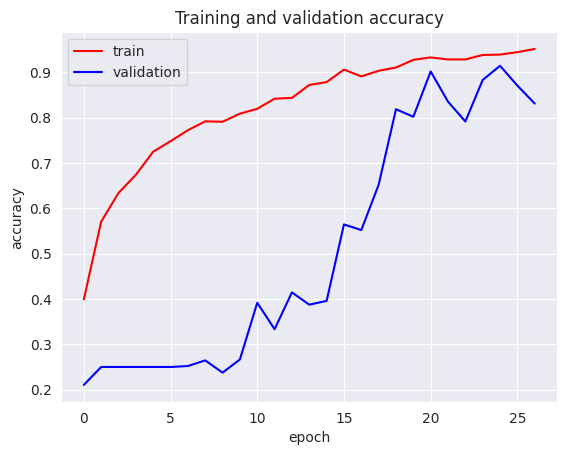

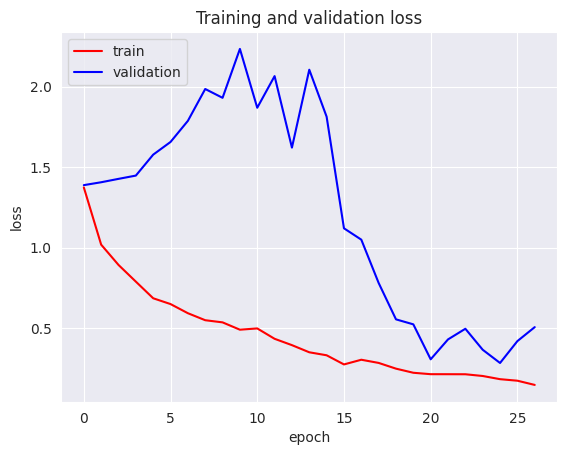

2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 8s/step - accuracy: 0.6667 - loss: 2.1546
Test Loss: 2.1807005405426025
Test Accuracy: 0.625


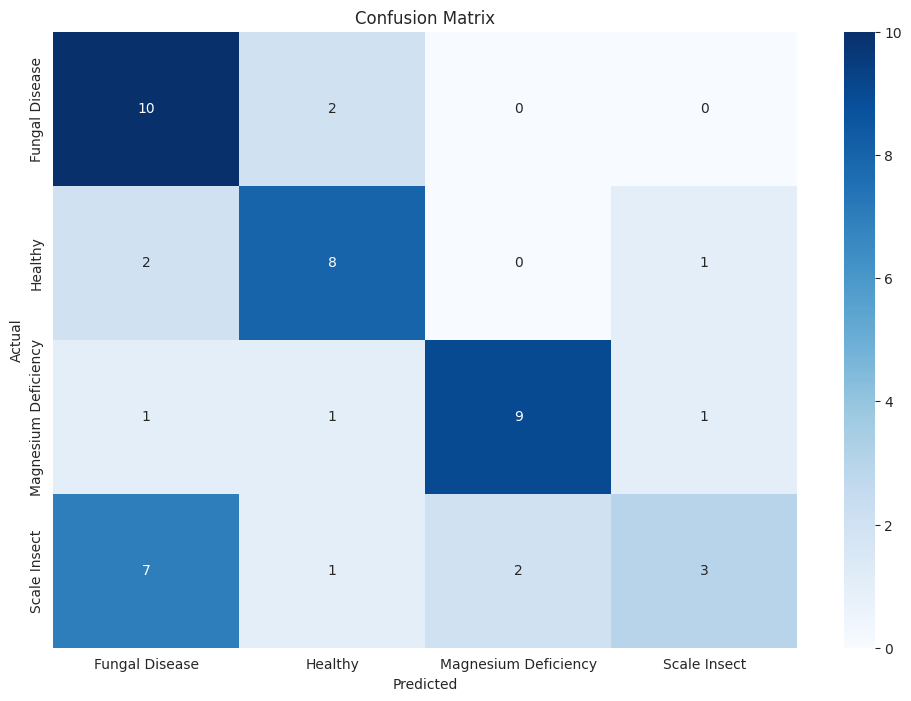

                      precision    recall  f1-score   support

      Fungal Disease       0.50      0.83      0.62        12
             Healthy       0.67      0.73      0.70        11
Magnesium Deficiency       0.82      0.75      0.78        12
        Scale Insect       0.60      0.23      0.33        13

            accuracy                           0.62        48
           macro avg       0.65      0.64      0.61        48
        weighted avg       0.64      0.62      0.60        48



In [13]:
with mlflow.start_run():
    # Fitting / training model
    history_model_1 = model_1.fit(
        train_generator,
        epochs=50,
        validation_data=validation_generator,
        callbacks=[checkpoint, reduce_lr, epoch_checkpoint]
    )

    # Menyimpan nilai metrik akurasi dan loss function setelah pelatihan
    acc_1 = history_model_1.history['accuracy']
    val_acc_1 = history_model_1.history['val_accuracy']
    loss_1 = history_model_1.history['loss']
    val_loss_1 = history_model_1.history['val_loss']
    epochs = range(len(acc_1))

    # Evaluating model
    plot_model_result(epochs, acc_1, val_acc_1, loss_1, val_loss_1)
    test_loss, test_accuracy = print_result_evaluating_model(model_1)
    show_model_report(model_1)

    # Log metric
    mlflow.log_metric("test_accuracy", test_accuracy)
    mlflow.log_metric("test_loss", test_loss)

    # Log artifact
    mlflow.log_artifact("test_confusion_matrix.png")

### **Model Transfer Learning (MobileNetV2)**

#### **Image Data Generator**

In [14]:
train_datagen = ImageDataGenerator(
    validation_split=0.3,
)
test_datagen = ImageDataGenerator()

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    seed=SEED,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    seed=SEED,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    seed=SEED,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(train_generator.class_indices)

Found 1120 images belonging to 4 classes.
Found 480 images belonging to 4 classes.
Found 48 images belonging to 4 classes.
{'Fungal Disease': 0, 'Healthy': 1, 'Magnesium Deficiency': 2, 'Scale Insect': 3}


#### **Init Model Transfer Learning**

In [15]:
# Melakukan inisiasi model dasar
base_model_tl = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

base_model_tl.trainable = False

# Membuat model baru
inputs = Input(shape=(224, 224, 3))
scale_layer = Rescaling(scale=1 / 127.5, offset=-1)(inputs)

x = base_model_tl(scale_layer, training=False)
x = GlobalAveragePooling2D()(x)
outputs = Dense(len(list_label), activation='softmax')(x)

model_tl = Model(inputs, outputs)

# Melatih model MobileNetV2 dengan data_tf baru
model_tl.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

model_tl.summary(show_trainable=True)

Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)                        ┃ Output Shape                 ┃       Param # ┃ Traina… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ input_layer_4 (InputLayer)          │ (None, 224, 224, 3)          │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ rescaling_1 (Rescaling)             │ (None, 224, 224, 3)          │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ mobilenetv2_1.00_224 (Functional)   │ (None, 7, 7, 1280)           │     2,257,984 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ global_average_pooling2d_2          │ (None, 1280)                 │             0 │    -    │
│ (GlobalAveragePooling2D)            │                              │               │         │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ dense_2 (Dense)                     │ (None, 4)                    │         5,124 │    Y    │
└─────────────────────────────────────┴──────────────────────────────┴───────────────┴─────────┘

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

#### **Extraction Feature, Fine Tuning, and Evaluating Model**

2025/06/12 17:00:09 WARNING mlflow.keras.autologging: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>. Dataset logging skipped.
2025/06/12 17:00:09 WARNING mlflow.keras.autologging: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>. Dataset logging skipped.
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.4982 - loss: 1.1926
Epoch 1: val_loss did not improve from 0.28211
35/35 ━━━━━━━━━━━━━━━━━━━━ 35s 731ms/step - accuracy: 0.5009 - loss: 1.1864 - val_accuracy: 0.7396 - val_loss: 0.6928
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.7944 - loss: 0.5649
Epoch 2: val_loss did not improve from 0.28211
35/35 ━━━━━━━━━━━━━━━━━━━━ 17s 508ms/step - accuracy: 0.7949 - loss: 0.5641 - val_accuracy: 0.8229 - val_loss: 0.5302
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8949 - loss: 0.3919
Epoch 3: val_loss did not improve from 0.28211
35/35 ━━━━━━━━━━━━━━━━━━━━ 18s 516ms/step - accuracy: 0.8948 - loss: 0.3918 - val_accuracy: 0.8521 - val_loss: 0.4404
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9223 - loss: 0.3050
Epoch 4: val_loss did not improve from 0.28211
35/35 ━━━━━━━━━━━━━━━━━━━━ 18s 514ms/step - accuracy: 0.9220 - loss: 0.3052 - val_accuracy: 0.8771 - val_loss: 0.3674


Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)                        ┃ Output Shape                 ┃       Param # ┃ Traina… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ input_layer_4 (InputLayer)          │ (None, 224, 224, 3)          │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ rescaling_1 (Rescaling)             │ (None, 224, 224, 3)          │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ mobilenetv2_1.00_224 (Functional)   │ (None, 7, 7, 1280)           │     2,257,984 │    Y    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ global_average_pooling2d_2          │ (None, 1280)                 │             0 │    -    │
│ (GlobalAveragePooling2D)            │                              │               │         │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ dense_2 (Dense)                     │ (None, 4)                    │         5,124 │    Y    │
└─────────────────────────────────────┴──────────────────────────────┴───────────────┴─────────┘

 Total params: 2,273,358 (8.67 MB)

 Trainable params: 2,228,996 (8.50 MB)

 Non-trainable params: 34,112 (133.25 KB)

 Optimizer params: 10,250 (40.04 KB)

2025/06/12 17:02:14 WARNING mlflow.keras.autologging: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>. Dataset logging skipped.
2025/06/12 17:02:14 WARNING mlflow.keras.autologging: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>. Dataset logging skipped.
2025/06/12 17:02:15 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: Changing param values is not allowed. Param with key='optimizer_learning_rate' was already logged with value='0.0010000000474974513' for run ID='2d46ac2096814243a9eafbdff6729b59'. Attempted logging new value '9.999999747378752e-06'.


Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.5351 - loss: 1.3865
Epoch 1: val_loss did not improve from 0.28211
35/35 ━━━━━━━━━━━━━━━━━━━━ 81s 731ms/step - accuracy: 0.5361 - loss: 1.3810 - val_accuracy: 0.8500 - val_loss: 0.4002
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.7433 - loss: 0.6866
Epoch 2: val_loss did not improve from 0.28211
35/35 ━━━━━━━━━━━━━━━━━━━━ 19s 551ms/step - accuracy: 0.7438 - loss: 0.6856 - val_accuracy: 0.8104 - val_loss: 0.4984
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.8280 - loss: 0.5048
Epoch 3: val_loss did not improve from 0.28211
35/35 ━━━━━━━━━━━━━━━━━━━━ 19s 556ms/step - accuracy: 0.8287 - loss: 0.5032 - val_accuracy: 0.7979 - val_loss: 0.5512
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.8995 - loss: 0.3313
Epoch 4: val_loss did not improve from 0.28211
35/35 ━━━━━━━━━━━━━━━━━━━━ 19s 552ms/step - accuracy: 0.8998 - loss: 0.3306 - val_accuracy: 0.7958 - val_loss: 0.5

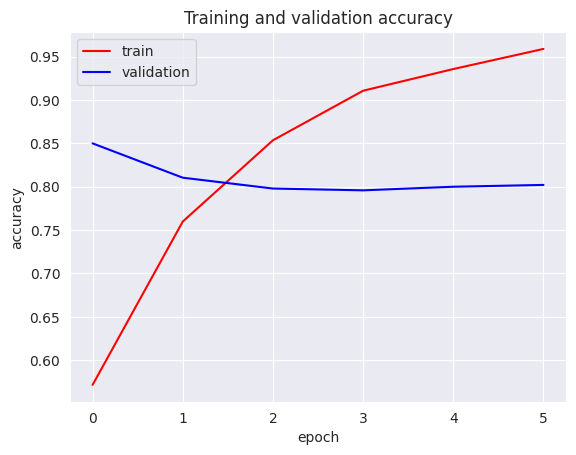

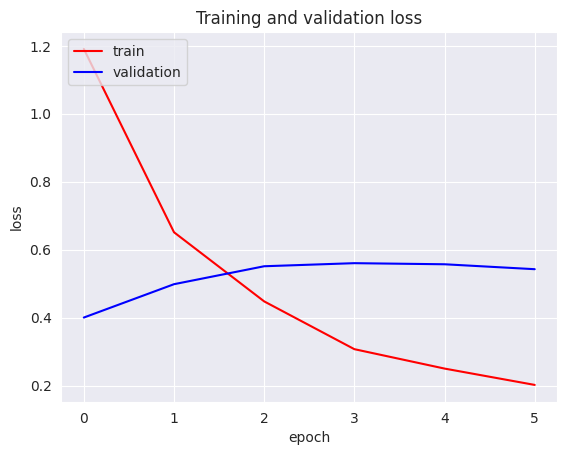

2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 4s/step - accuracy: 0.6875 - loss: 0.7697
Test Loss: 0.7664493918418884
Test Accuracy: 0.6875


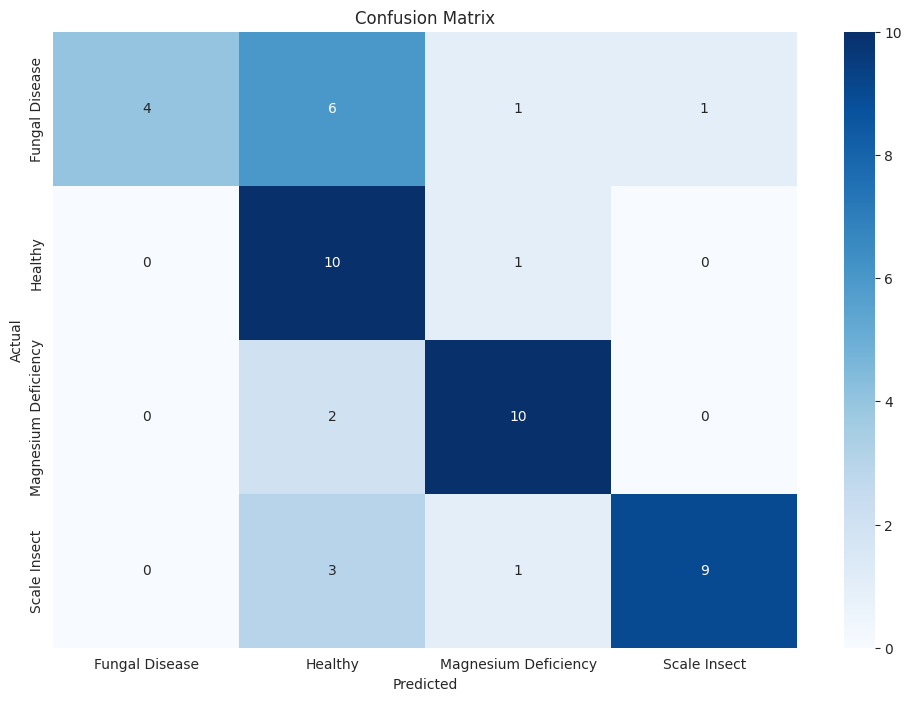

                      precision    recall  f1-score   support

      Fungal Disease       1.00      0.33      0.50        12
             Healthy       0.48      0.91      0.62        11
Magnesium Deficiency       0.77      0.83      0.80        12
        Scale Insect       0.90      0.69      0.78        13

            accuracy                           0.69        48
           macro avg       0.79      0.69      0.68        48
        weighted avg       0.80      0.69      0.68        48



In [16]:
# Melakukan proses ekstraksi fitur
with mlflow.start_run():
    # Log informasi base model
    mlflow.log_param("base_model", "MobileNetV2")
    mlflow.log_param("base_model_trainable", False)
    mlflow.log_param("new_layers", "Rescaling, GlobalAverage2D, Dense(256), Dense(4)")

    # Log base model summary
    with open("base_model_summary.txt", "w") as f:
        base_model_tl.summary(print_fn=lambda z: f.write(z + "\n"))
    mlflow.log_artifact("base_model_summary.txt")

    # Log model visualization
    tf.keras.utils.plot_model(model_tl, to_file="model_architecture.png", show_shapes=True)
    mlflow.log_artifact("model_architecture.png")

    # Extraction feature
    model_tl.fit(
        train_generator,
        epochs=50,
        validation_data=validation_generator,
        callbacks=[checkpoint, epoch_checkpoint]
    )

    # Memulai proses fine tuning
    base_model_tl.trainable = True
    model_tl.summary(show_trainable=True)

    model_tl.compile(
        optimizer=Adam(1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history_model_tl = model_tl.fit(
        train_generator,
        epochs=50,
        validation_data=validation_generator,
        callbacks=[checkpoint, epoch_checkpoint]
    )

    acc_tl = history_model_tl.history['accuracy']
    val_acc_tl = history_model_tl.history['val_accuracy']
    loss_tl = history_model_tl.history['loss']
    val_loss_tl = history_model_tl.history['val_loss']

    epochs = range(len(acc_tl))

    # Evaluating model
    plot_model_result(epochs, acc_tl, val_acc_tl, loss_tl, val_loss_tl)
    test_loss, test_accuracy = print_result_evaluating_model(model_tl)
    show_model_report(model_tl)

    # Log metric
    mlflow.log_metric("test_accuracy", test_accuracy)
    mlflow.log_metric("test_loss", test_loss)

    # Log artifact
    mlflow.log_artifact("test_confusion_matrix.png")

### **Model Transfer Learning (ResNet50)**

#### **Image Data Generator**

In [17]:
train_datagen = ImageDataGenerator(
    validation_split=0.3,
)
test_datagen = ImageDataGenerator()

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    seed=SEED,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    seed=SEED,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    seed=SEED,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(train_generator.class_indices)

Found 1120 images belonging to 4 classes.
Found 480 images belonging to 4 classes.
Found 48 images belonging to 4 classes.
{'Fungal Disease': 0, 'Healthy': 1, 'Magnesium Deficiency': 2, 'Scale Insect': 3}


#### **Init Model Transfer Learning**

In [18]:
base_model_resnet = ResNet50V2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

base_model_resnet.trainable = False

input_resnet = Input(shape=(224, 224, 3))
resnet_scale_layer = Rescaling(scale=1 / 127.5, offset=-1)(input_resnet)

x = base_model_resnet(resnet_scale_layer, training=False)
x = GlobalAveragePooling2D()(x)
output = Dense(len(list_label), activation='softmax')(x)

model_resnet = Model(input_resnet, output)

# Melatih model ResNet50V2
model_resnet.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

model_resnet.summary(show_trainable=True)

Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)                        ┃ Output Shape                 ┃       Param # ┃ Traina… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ input_layer_6 (InputLayer)          │ (None, 224, 224, 3)          │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ rescaling_2 (Rescaling)             │ (None, 224, 224, 3)          │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ resnet50v2 (Functional)             │ (None, 7, 7, 2048)           │    23,564,800 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ global_average_pooling2d_3          │ (None, 2048)                 │             0 │    -    │
│ (GlobalAveragePooling2D)            │                              │               │         │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ dense_3 (Dense)                     │ (None, 4)                    │         8,196 │    Y    │
└─────────────────────────────────────┴──────────────────────────────┴───────────────┴─────────┘

 Total params: 23,572,996 (89.92 MB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 23,564,800 (89.89 MB)

#### **Extraction Feature, Fine Tuning, and Evaluating Model**

2025/06/12 17:05:39 WARNING mlflow.keras.autologging: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>. Dataset logging skipped.
2025/06/12 17:05:39 WARNING mlflow.keras.autologging: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>. Dataset logging skipped.
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.4389 - loss: 1.3517
Epoch 1: val_loss did not improve from 0.28211
35/35 ━━━━━━━━━━━━━━━━━━━━ 40s 714ms/step - accuracy: 0.4424 - loss: 1.3439 - val_accuracy: 0.7479 - val_loss: 0.6771
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.7841 - loss: 0.5841
Epoch 2: val_loss did not improve from 0.28211
35/35 ━━━━━━━━━━━━━━━━━━━━ 18s 530ms/step - accuracy: 0.7846 - loss: 0.5833 - val_accuracy: 0.8208 - val_loss: 0.5101
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.8614 - loss: 0.4341
Epoch 3: val_loss did not improve from 0.28211
35/35 ━━━━━━━━━━━━━━━━━━━━ 21s 604ms/step - accuracy: 0.8616 - loss: 0.4336 - val_accuracy: 0.8729 - val_loss: 0.4344
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9175 - loss: 0.3258
Epoch 4: val_loss did not improve from 0.28211
35/35 ━━━━━━━━━━━━━━━━━━━━ 18s 534ms/step - accuracy: 0.9175 - loss: 0.3257 - val_accuracy: 0.8917 - val_loss: 0.3630


Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)                        ┃ Output Shape                 ┃       Param # ┃ Traina… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ input_layer_6 (InputLayer)          │ (None, 224, 224, 3)          │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ rescaling_2 (Rescaling)             │ (None, 224, 224, 3)          │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ resnet50v2 (Functional)             │ (None, 7, 7, 2048)           │    23,564,800 │    Y    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ global_average_pooling2d_3          │ (None, 2048)                 │             0 │    -    │
│ (GlobalAveragePooling2D)            │                              │               │         │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ dense_3 (Dense)                     │ (None, 4)                    │         8,196 │    Y    │
└─────────────────────────────────────┴──────────────────────────────┴───────────────┴─────────┘

 Total params: 23,589,390 (89.99 MB)

 Trainable params: 23,527,556 (89.75 MB)

 Non-trainable params: 45,440 (177.50 KB)

 Optimizer params: 16,394 (64.04 KB)

2025/06/12 17:07:53 WARNING mlflow.keras.autologging: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>. Dataset logging skipped.
2025/06/12 17:07:53 WARNING mlflow.keras.autologging: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>. Dataset logging skipped.
2025/06/12 17:07:54 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: Changing param values is not allowed. Param with key='optimizer_learning_rate' was already logged with value='0.0010000000474974513' for run ID='baae206af0284c9884ff61459090ca15'. Attempted logging new value '9.999999747378752e-06'.


Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.6360 - loss: 0.9450
Epoch 1: val_loss did not improve from 0.28211
35/35 ━━━━━━━━━━━━━━━━━━━━ 97s 934ms/step - accuracy: 0.6375 - loss: 0.9407 - val_accuracy: 0.9021 - val_loss: 0.3290
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.9083 - loss: 0.3239
Epoch 2: val_loss did not improve from 0.28211
35/35 ━━━━━━━━━━━━━━━━━━━━ 25s 725ms/step - accuracy: 0.9087 - loss: 0.3231 - val_accuracy: 0.9167 - val_loss: 0.2922
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.9702 - loss: 0.1843
Epoch 3: val_loss improved from 0.28211 to 0.23413, saving model to best_model.h5

Akurasi telah mencapai >95%
35/35 ━━━━━━━━━━━━━━━━━━━━ 26s 757ms/step - accuracy: 0.9703 - loss: 0.1842 - val_accuracy: 0.9333 - val_loss: 0.2341


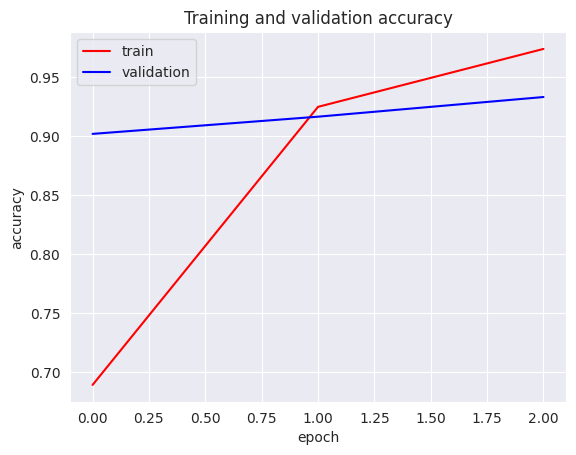

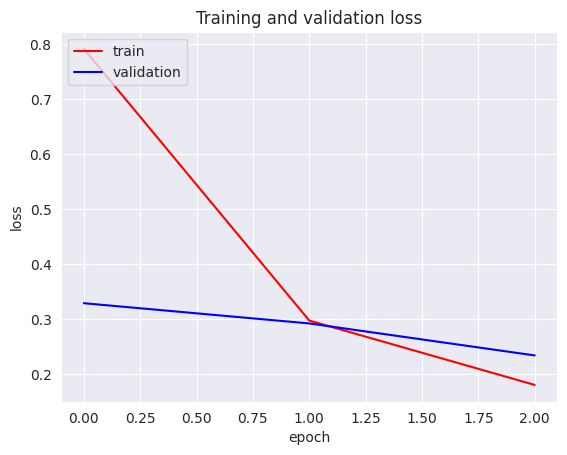

2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 6s/step - accuracy: 0.7639 - loss: 0.6679
Test Loss: 0.60996413230896
Test Accuracy: 0.7708333134651184


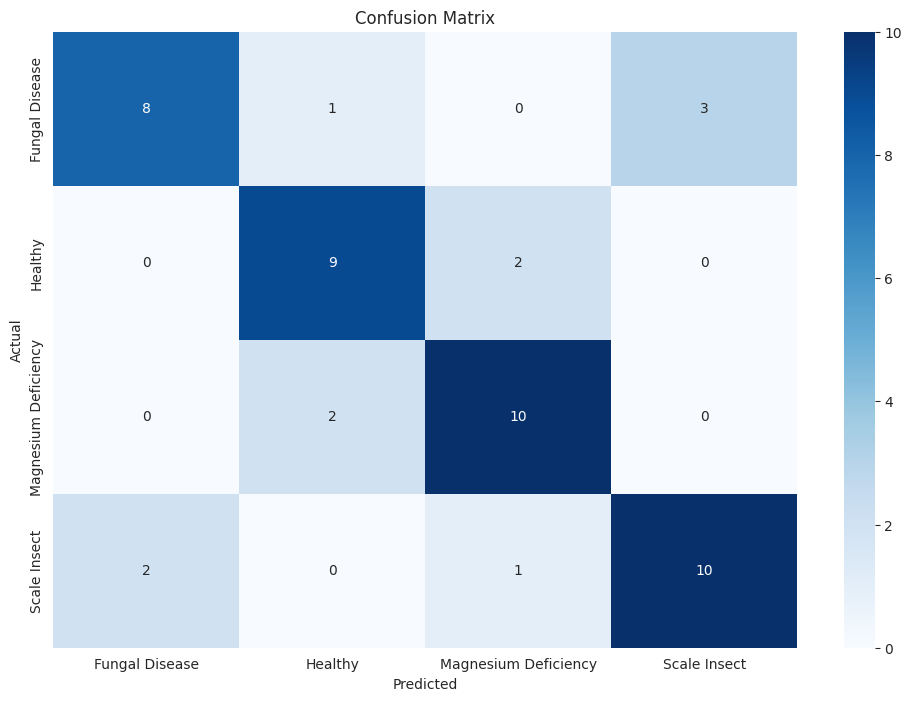

                      precision    recall  f1-score   support

      Fungal Disease       0.80      0.67      0.73        12
             Healthy       0.75      0.82      0.78        11
Magnesium Deficiency       0.77      0.83      0.80        12
        Scale Insect       0.77      0.77      0.77        13

            accuracy                           0.77        48
           macro avg       0.77      0.77      0.77        48
        weighted avg       0.77      0.77      0.77        48



In [19]:
# Melakukan proses ekstraksi fitur
with mlflow.start_run():
    # Log informasi base model
    mlflow.log_param("base_model", "ResNest50V2")
    mlflow.log_param("base_model_trainable", False)
    mlflow.log_param("new_layers", "Rescaling, GlobalAverage2D, Dense(256), Dense(4)")

    # Log base model summary
    with open("base_model_summary.txt", "w") as f:
        base_model_resnet.summary(print_fn=lambda z: f.write(z + "\n"))
    mlflow.log_artifact("base_model_summary.txt")

    # Log model visualization
    tf.keras.utils.plot_model(model_resnet, to_file="model_architecture.png", show_shapes=True)
    mlflow.log_artifact("model_architecture.png")

    model_resnet.fit(
        train_generator,
        epochs=50,
        validation_data=validation_generator,
        callbacks=[checkpoint, epoch_checkpoint]
    )

    # Memulai proses fine tuninng
    base_model_resnet.trainable = True
    model_resnet.summary(show_trainable=True)

    model_resnet.compile(
        optimizer=Adam(1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history_model_resnet = model_resnet.fit(
        train_generator,
        epochs=50,
        validation_data=validation_generator,
        callbacks=[checkpoint, epoch_checkpoint]
    )

    # Evaluating model
    acc_resnet = history_model_resnet.history['accuracy']
    val_acc_resnet = history_model_resnet.history['val_accuracy']
    loss_resnet = history_model_resnet.history['loss']
    val_loss_resnet = history_model_resnet.history['val_loss']
    epochs_resnet = range(len(acc_resnet))

    plot_model_result(epochs_resnet, acc_resnet, val_acc_resnet, loss_resnet, val_loss_resnet)
    test_loss, test_accuracy = print_result_evaluating_model(model_resnet)
    show_model_report(model_resnet)

    # Log metric
    mlflow.log_metric("test_accuracy", test_accuracy)
    mlflow.log_metric("test_loss", test_loss)

   # Log artifact
    mlflow.log_artifact("test_confusion_matrix.png")

### **Model Transfer Learning (Xception)**

#### **Image Data Generator**

In [20]:
train_datagen = ImageDataGenerator(
    validation_split=0.3,
)
test_datagen = ImageDataGenerator()

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    seed=SEED,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    subset='training'
)

validation_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    seed=SEED,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    seed=SEED,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(train_generator.class_indices)

Found 1120 images belonging to 4 classes.
Found 480 images belonging to 4 classes.
Found 48 images belonging to 4 classes.
{'Fungal Disease': 0, 'Healthy': 1, 'Magnesium Deficiency': 2, 'Scale Insect': 3}


#### **Init Model Xception**

In [21]:
base_model_xception = Xception(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

base_model_xception.trainable = False

input_xception = Input(shape=(224, 224, 3))
xception_scale_layer = Rescaling(scale=1 / 127.5, offset=-1)(input_xception)

x_xception = base_model_xception(xception_scale_layer, training=False)
x_xception = GlobalAveragePooling2D()(x_xception)
output_xception = Dense(len(list_label), activation='softmax')(x_xception)

model_xception = Model(input_xception, output_xception)
model_xception.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

model_xception.summary(show_trainable=True)

Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)                        ┃ Output Shape                 ┃       Param # ┃ Traina… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ input_layer_8 (InputLayer)          │ (None, 224, 224, 3)          │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ rescaling_3 (Rescaling)             │ (None, 224, 224, 3)          │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ xception (Functional)               │ (None, 7, 7, 2048)           │    20,861,480 │    N    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ global_average_pooling2d_4          │ (None, 2048)                 │             0 │    -    │
│ (GlobalAveragePooling2D)            │                              │               │         │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ dense_4 (Dense)                     │ (None, 4)                    │         8,196 │    Y    │
└─────────────────────────────────────┴──────────────────────────────┴───────────────┴─────────┘

 Total params: 20,869,676 (79.61 MB)

 Trainable params: 8,196 (32.02 KB)

 Non-trainable params: 20,861,480 (79.58 MB)

#### **Extraction Feature, Fine Tuning, and Evaluating Model**

2025/06/12 17:10:54 WARNING mlflow.keras.autologging: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>. Dataset logging skipped.
2025/06/12 17:10:54 WARNING mlflow.keras.autologging: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>. Dataset logging skipped.
/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.3871 - loss: 1.2621
Epoch 1: val_loss did not improve from 0.23413
35/35 ━━━━━━━━━━━━━━━━━━━━ 43s 850ms/step - accuracy: 0.3912 - loss: 1.2570 - val_accuracy: 0.6896 - val_loss: 0.8185
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.7563 - loss: 0.6871
Epoch 2: val_loss did not improve from 0.23413
35/35 ━━━━━━━━━━━━━━━━━━━━ 22s 643ms/step - accuracy: 0.7566 - loss: 0.6863 - val_accuracy: 0.7542 - val_loss: 0.6630
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.8151 - loss: 0.5364
Epoch 3: val_loss did not improve from 0.23413
35/35 ━━━━━━━━━━━━━━━━━━━━ 22s 630ms/step - accuracy: 0.8152 - loss: 0.5361 - val_accuracy: 0.7896 - val_loss: 0.5810
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.8555 - loss: 0.4528
Epoch 4: val_loss did not improve from 0.23413
35/35 ━━━━━━━━━━━━━━━━━━━━ 22s 641ms/step - accuracy: 0.8556 - loss: 0.4525 - val_accuracy: 0.8208 - val_loss: 0.5

Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)                        ┃ Output Shape                 ┃       Param # ┃ Traina… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ input_layer_8 (InputLayer)          │ (None, 224, 224, 3)          │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ rescaling_3 (Rescaling)             │ (None, 224, 224, 3)          │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ xception (Functional)               │ (None, 7, 7, 2048)           │    20,861,480 │    Y    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ global_average_pooling2d_4          │ (None, 2048)                 │             0 │    -    │
│ (GlobalAveragePooling2D)            │                              │               │         │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ dense_4 (Dense)                     │ (None, 4)                    │         8,196 │    Y    │
└─────────────────────────────────────┴──────────────────────────────┴───────────────┴─────────┘

 Total params: 20,886,070 (79.67 MB)

...

 Optimizer params: 16,394 (64.04 KB)

2025/06/12 17:14:31 WARNING mlflow.keras.autologging: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>. Dataset logging skipped.
2025/06/12 17:14:31 WARNING mlflow.keras.autologging: Unrecognized dataset type <class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>. Dataset logging skipped.
2025/06/12 17:14:31 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during autologging: Changing param values is not allowed. Param with key='optimizer_learning_rate' was already logged with value='0.0010000000474974513' for run ID='6232881623a94a64a8e0b58a773bd5a3'. Attempted logging new value '9.999999747378752e-06'.


Epoch 1/50


E0000 00:00:1749748521.494763    2625 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1749748521.681556    2625 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1749748522.960144    2625 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1749748523.100725    2625 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 572ms/step - accuracy: 0.6666 - loss: 0.8750
Epoch 1: val_loss did not improve from 0.23413
35/35 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.6671 - loss: 0.8738 - val_accuracy: 0.8646 - val_loss: 0.3491
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 542ms/step - accuracy: 0.8476 - loss: 0.5516
Epoch 2: val_loss did not improve from 0.23413
35/35 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.8479 - loss: 0.5506 - val_accuracy: 0.8646 - val_loss: 0.3270
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 573ms/step - accuracy: 0.9315 - loss: 0.3698
Epoch 3: val_loss did not improve from 0.23413
35/35 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.9316 - loss: 0.3690 - val_accuracy: 0.8938 - val_loss: 0.2892
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 536ms/step - accuracy: 0.9679 - loss: 0.2507
Epoch 4: val_loss did not improve from 0.23413

Akurasi telah mencapai >95%
35/35 ━━━━━━━━━━━━━━━━━━━━ 35s 1000ms/step - accuracy: 0.9676 - loss: 0.2509 - val_accuracy: 0.9021 - va

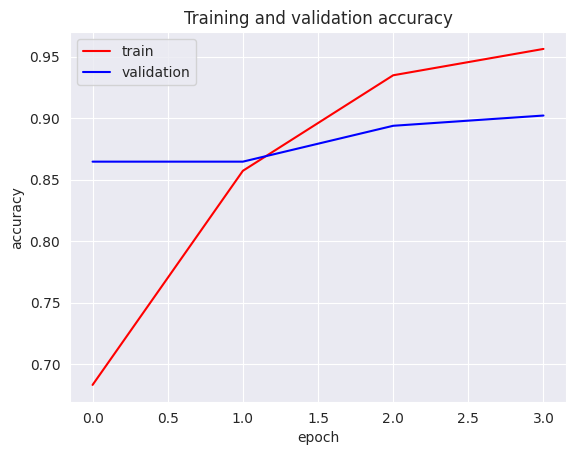

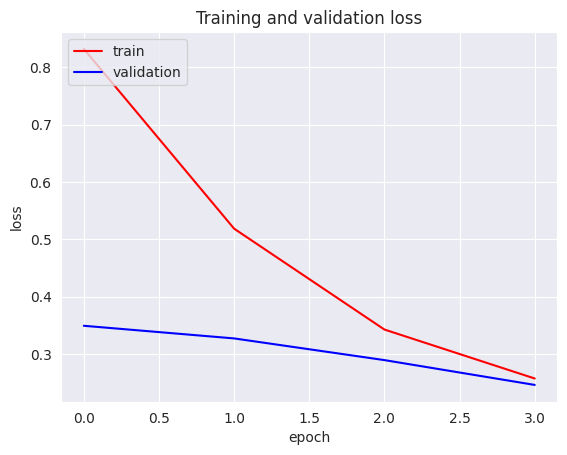

2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 6s/step - accuracy: 0.8472 - loss: 0.5072
Test Loss: 0.5182592868804932
Test Accuracy: 0.8333333134651184


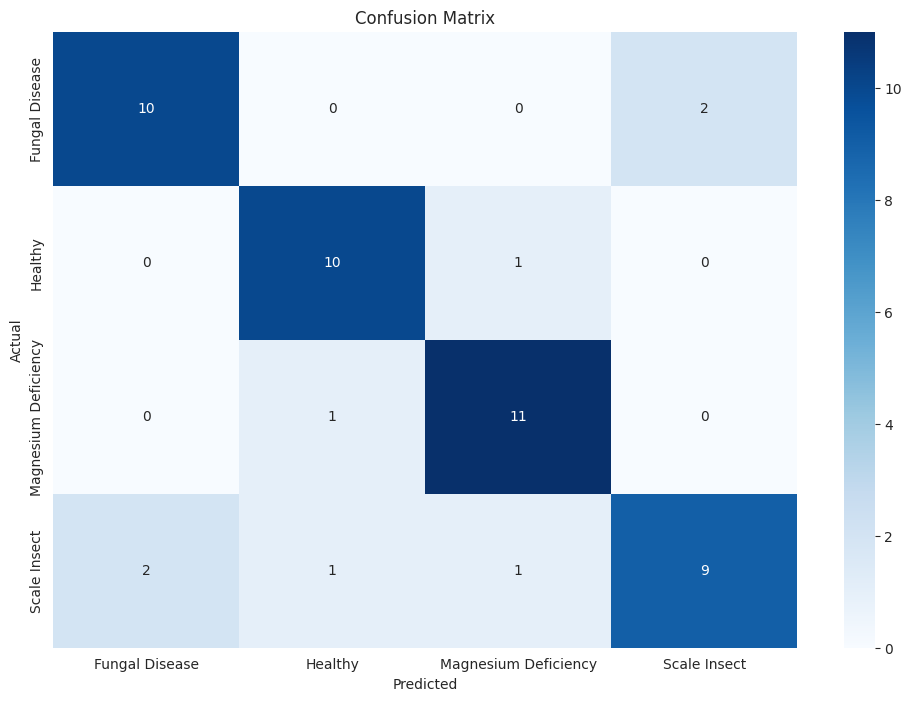

                      precision    recall  f1-score   support

      Fungal Disease       0.83      0.83      0.83        12
             Healthy       0.83      0.91      0.87        11
Magnesium Deficiency       0.85      0.92      0.88        12
        Scale Insect       0.82      0.69      0.75        13

            accuracy                           0.83        48
           macro avg       0.83      0.84      0.83        48
        weighted avg       0.83      0.83      0.83        48



In [22]:
with mlflow.start_run():
    # Log informasi base model
    mlflow.log_param("base_model", "Xception")
    mlflow.log_param("base_model_trainable", False)
    mlflow.log_param("new_layers", "Rescaling, GlobalAverage2D, Dense(256), Dense(4)")

    # Log base model summary
    with open("base_model_summary.txt", "w") as f:
        base_model_xception.summary(print_fn=lambda z: f.write(z + "\n"))
    mlflow.log_artifact("base_model_summary.txt")

    # Log model visualization
    tf.keras.utils.plot_model(model_xception, to_file="model_architecture.png", show_shapes=True)
    mlflow.log_artifact("model_architecture.png")

    model_xception.fit(
        train_generator,
        epochs=50,
        validation_data=validation_generator,
        callbacks=[checkpoint, epoch_checkpoint]
    )

    base_model_xception.trainable = True

    # Fine tuning
    model_xception.summary(show_trainable=True)

    model_xception.compile(
        optimizer=Adam(1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history_model_xception = model_xception.fit(
        train_generator,
        epochs=50,
        validation_data=validation_generator,
        callbacks=[checkpoint, epoch_checkpoint]
    )

    # Evaluating Model
    acc_xception = history_model_xception.history['accuracy']
    val_acc_xcpetion = history_model_xception.history['val_accuracy']
    loss_xception = history_model_xception.history['loss']
    val_loss_xception = history_model_xception.history['val_loss']
    epochs_xception = range(len(acc_xception))

    plot_model_result(epochs_xception, acc_xception, val_acc_xcpetion, loss_xception, val_loss_xception)
    test_loss, test_accuracy = print_result_evaluating_model(model_xception)
    show_model_report(model_xception)

    # Log metric
    mlflow.log_metric("test_accuracy", test_accuracy)
    mlflow.log_metric("test_loss", test_loss)

    # Log artifact
    mlflow.log_artifact("test_confusion_matrix.png")

## **Inferring Model**

### **Preprocessing Predict Image**

In [23]:
list_label = ['Fungal Disease', 'Healthy', 'Magnesium Deficiency', 'Scale Insect']


# Membuat fungsi untuk menampilkan gambar yang akan diprediski
def show_image(img_predict_path):
    test_img = image.load_img(img_predict_path, target_size=(224, 224))
    plt.imshow(test_img)
    plt.axis("off")
    plt.title("Image Input")
    plt.show()


# Memproses gambar inputan menjadi matriks
def preprocessing_img(img_predict_path):
    test_img = image.load_img(img_predict_path, target_size=(224, 224))

    img_array = image.img_to_array(test_img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    img_tensor = tf.constant(img_array, dtype=tf.float32)
    return img_tensor


# Membuat fungsi untuk melakukan pemrosesan gambar untuk model MobileNetV2
def preprocessing_img_for_mobile_net(img_predict_path):
    test_img = image.load_img(img_predict_path, target_size=(224, 224))
    img_array = image.img_to_array(test_img)
    img_array = np.expand_dims(img_array, axis=0)

    img_tensor = tf.constant(img_array, dtype=tf.float32)
    return img_tensor


# Membuat fungsi untuk melakukan prediksi
def predict_img(inferring_model, img_predict_path, preprocessing_img_func):
    predict = inferring_model.predict(preprocessing_img_func(img_predict_path))

    predict_output = None

    if isinstance(predict, tuple):
        predict_output = predict['output_0']
    elif isinstance(predict, list):
        predict_output = predict[0]
    elif isinstance(predict, np.ndarray):
        predict_output = predict

    single_img_probably = predict_output[0]

    class_probably_list = []
    for i, prob in enumerate(single_img_probably):
        class_probably_list.append((list_label[i], prob))

    predict_results = {}

    class_probably_sorted = sorted(class_probably_list, key=lambda x: x[1], reverse=True)
    for class_name, prob in class_probably_sorted:
        predict_results[class_name] = f"{prob * 100:.2f}%"

    return predict_results


print(list_label)

['Fungal Disease', 'Healthy', 'Magnesium Deficiency', 'Scale Insect']


### **Download Predict Image from Google Drive**

In [24]:
# Mengunduh gambar prediksi dari Google Drive
file_predict_id = "1MyxbfVFSxRLmAb4rfHKe78ErtPPdd00Y"
url_predict = f"https://drive.google.com/uc?id={file_predict_id}"
gdown.download(url_predict, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1MyxbfVFSxRLmAb4rfHKe78ErtPPdd00Y
To: /kaggle/working/palm-oil-inference.zip
100%|██████████| 1.35M/1.35M [00:00<00:00, 107MB/s]


'palm-oil-inference.zip'

In [25]:
# Unzip berkas yang telah diunduh dari Google Drive
with zipfile.ZipFile('palm-oil-inference.zip', 'r') as zip_file:
    zip_file.extractall()

print("Berhasil melakukan unzip")

Berhasil melakukan unzip


### **Inferring Model**

In [26]:
def batch_test_model(img_predict, models):
    fig_test, ax_test = plt.subplots(1, len(models), figsize=(12, 5))

    for i_test, model_test in enumerate(models):
        predict_result_detail = ""

        test_image = Image.open(img_predict)

        predict_result = predict_img(model_test[1], img_predict, model_test[2])

        for j_test in predict_result:
            predict_result_detail += f"{j_test}: {predict_result[j_test]}\n"

        ax_test[i_test].imshow(test_image)
        ax_test[i_test].set_title(model_test[0], fontsize=16)
        ax_test[i_test].set(xticks=[], yticks=[])
        ax_test[i_test].set_xlabel(predict_result_detail, fontsize=16)

    fig_test.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


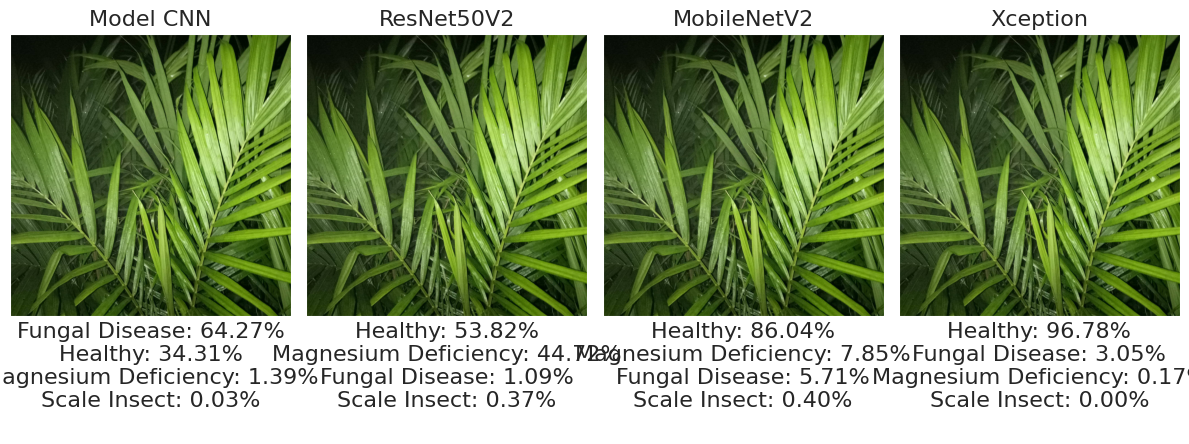

In [33]:
img_predict_1 = "palm-test-inference/Healthy.jpg"

list_model = [
    ("Model CNN", model_1, preprocessing_img),
    ("ResNet50V2", model_resnet, preprocessing_img_for_mobile_net),
    ("MobileNetV2", model_tl, preprocessing_img_for_mobile_net),
    ("Xception", model_xception, preprocessing_img_for_mobile_net),
]

batch_test_model(img_predict_1, list_model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


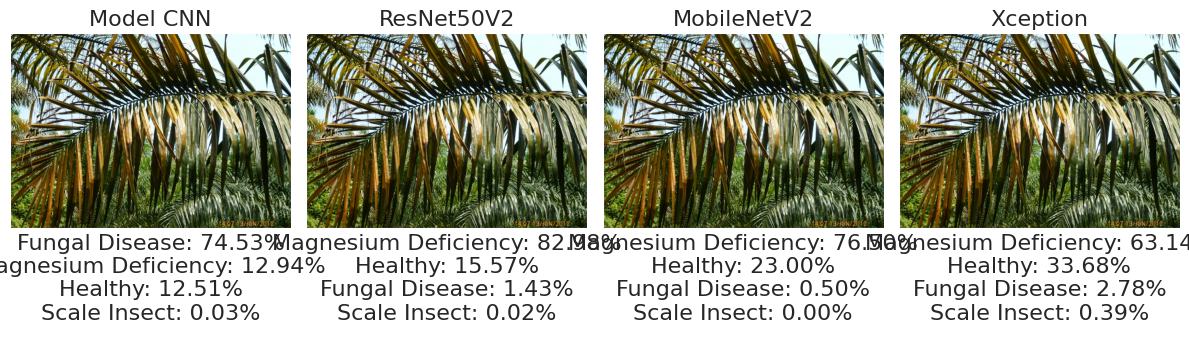

In [34]:
img_predict_2 = "palm-test-inference/Magnesium Deficiency.jpg"
batch_test_model(img_predict_2, list_model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


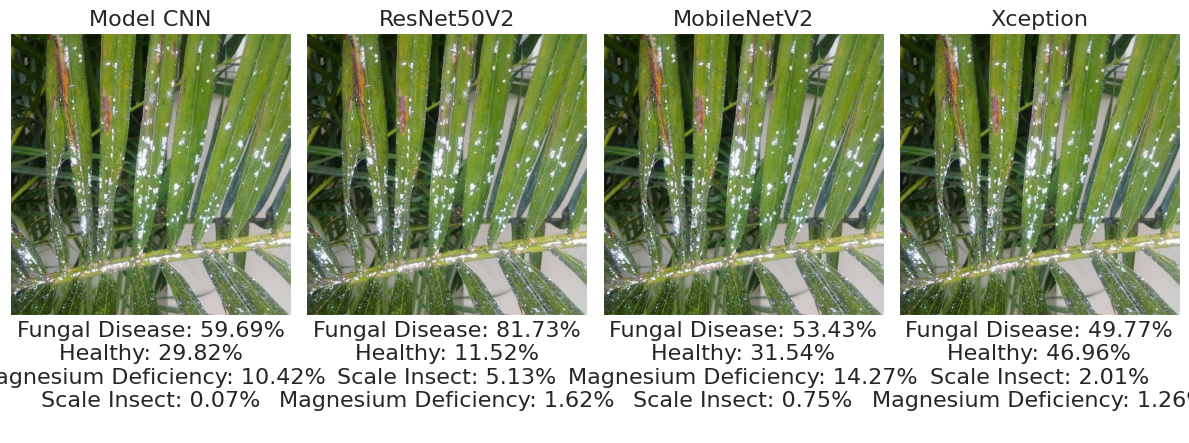

In [35]:
# Menampilkan gambar prediksi
img_predict_3 = "palm-test-inference/Scale Insect.jpg"
batch_test_model(img_predict_3, list_model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


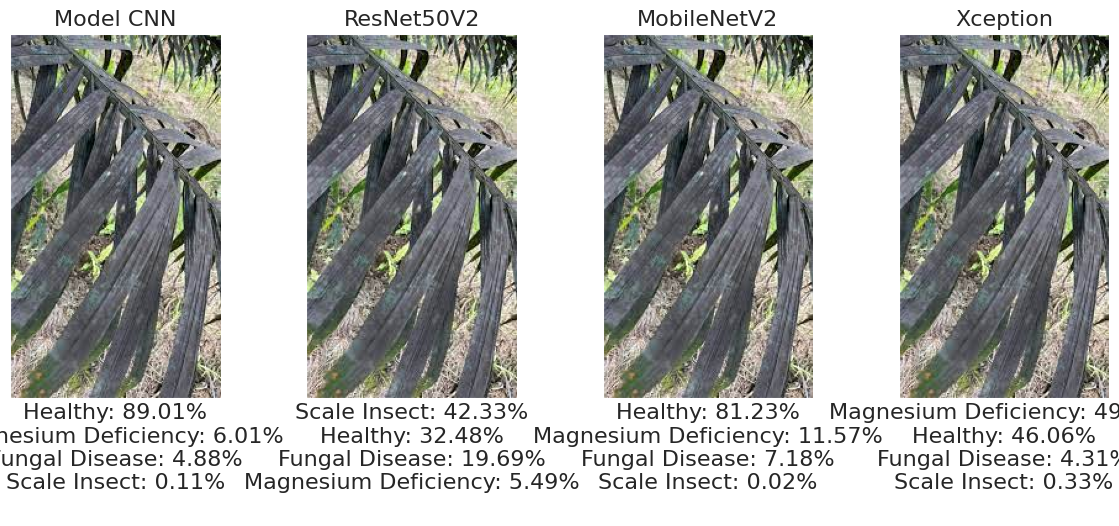

In [36]:
img_predict_4 = "palm-test-inference/Fungal Disease.jpeg"
batch_test_model(img_predict_4, list_model)

## **Converting Model**

### **Converting Model to SavedModel Format**

In [31]:
# Konversi model ke format SavedModel
saved_path = '/kaggle/working/model/saved_model'
save(model_xception, saved_path)

### **Converting SavedModel to ZIP (Kaggle Notebook)**

In [32]:
model_folder_name = "model/saved_model"
saved_model_path = "/kaggle/working/model/saved_model/"

zip_file_name = "palm-oil-model.zip"
zip_file_path = os.path.join("/kaggle", "working", zip_file_name)

if os.path.exists(saved_model_path):
    print(f"Mengkompres folder '{saved_model_path}' menjadi '{zip_file_name}'")

    working_dir = os.getcwd()
    os.chdir(saved_model_path)

    try:
        !zip -r {zip_file_name} .
        print(f"Berhasil mengkompres model ke: {zip_file_path}")

        # Membuat link download
        display(FileLink(zip_file_name))
    except Exception as e:
        print(f"Unexpected error: {e}")
    finally:
        os.chdir(working_dir)

else:
    print(f"Error: folder model '{model_folder_name}' tidak ditemukan di '{saved_model_path}'")

Mengkompres folder '/kaggle/working/model/saved_model/' menjadi 'palm-oil-model.zip'
  adding: saved_model.pb (deflated 91%)
  adding: assets/ (stored 0%)
  adding: variables/ (stored 0%)
  adding: variables/variables.data-00000-of-00001 (deflated 8%)
  adding: variables/variables.index (deflated 78%)
  adding: fingerprint.pb (stored 0%)
Berhasil mengkompres model ke: /kaggle/working/palm-oil-model.zip


/kaggle/working/model/saved_model/palm-oil-model.zip